In [1]:
pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 968.6/968.6 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.0 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=255e18ee981030f135aaa8cc6f9421f6931bd9d5b758227bb2207c91ac10152b
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator


Level 1 — MLP neurons — IOI task

This notebook applies the Level 1 (neuron / parameter) analysis to the **IOI task** on GPT-2 Small,
mirroring the structure of `02_level1_neurons.ipynb` used for the grokking task.

**Components**: individual post-ReLU neurons across all 12 MLP sublayers of GPT-2 Small
(12 × 3,072 = 36,864 neurons total). Post-ReLU activations (`blocks.{l}.mlp.hook_post`) at
the final token position are the signals ablated and restored.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import random
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer

torch.manual_seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level1IOI")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Using device: cuda


In [3]:
model = HookedTransformer.from_pretrained(
    "gpt2",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
)
model.cfg.use_attn_result = True
model.eval()
model.to(device)

N_LAYERS = model.cfg.n_layers   # 12
D_MLP    = model.cfg.d_mlp      # 3072
print(f"Layers: {N_LAYERS}  D_MLP: {D_MLP}  D_model: {model.cfg.d_model}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda
Layers: 12  D_MLP: 3072  D_model: 768


Build the IOI dataset

Identical dataset to `03bis_level2_heads(IOI).ipynb`.
pIOI uses two names (IO and S); pABC uses three unrelated names to destroy the
duplication signal while preserving grammatical structure.

In [4]:
NAMES = [
    "Mary", "John", "Alice", "Bob", "Emma", "Frank", "Grace", "Henry",
    "Iris", "Jack", "Kate", "Liam", "Mia", "Noah", "Olivia", "Paul",
    "Rose", "Sam", "Tina", "Victor", "Wendy", "Anna", "Brian", "Clara",
    "Elena", "Felix", "Gina", "Harry", "Jake", "Luna", "Mark", "Nina",
    "Oscar", "Pam", "Ray", "Sara", "Tom", "Vera", "Will", "Zoe"
]
PLACES  = ["store", "school", "park", "office", "market", "gym",
           "beach", "hotel", "library", "theater", "hospital", "mall"]
OBJECTS = ["drink", "book", "ball", "bag", "gift", "key",
           "pen", "hat", "ring", "card", "toy", "cup"]

TEMPLATES = [
    "Then, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] were working at the [PLACE]. [S] decided to give a [OBJECT] to",
    "Then, [IO] and [S] were thinking about going to the [PLACE]. [S] wanted to give a [OBJECT] to",
    "After [IO] and [S] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [IO] and [S] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [IO] and [S] were working at the [PLACE], [S] gave a [OBJECT] to",
    "While [IO] and [S] were commuting to the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [IO] and [S] went to had a [OBJECT]. [S] gave it to",
    "Friends [IO] and [S] found a [OBJECT] at the [PLACE]. [S] gave it to",
    "Then, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [S] and [IO] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "After [S] and [IO] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [S] and [IO] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [S] and [IO] were working at the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [S] and [IO] went to had a [OBJECT]. [S] gave it to",
]

def build_dataset(N, use_abc=False, seed=42):
    rng = random.Random(seed)
    dataset = []
    for i in range(N):
        template = rng.choice(TEMPLATES)
        place    = rng.choice(PLACES)
        obj      = rng.choice(OBJECTS)
        if use_abc:
            a, b, c = rng.sample(NAMES, 3)
            prompt = (template
                        .replace("[IO]", a)
                        .replace("[S]", b, 1)
                        .replace("[S]", c)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
            io_name, s_name = a, b
        else:
            io_name, s_name = rng.sample(NAMES, 2)
            prompt = (template
                        .replace("[IO]", io_name)
                        .replace("[S]", s_name)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
        dataset.append({"prompt": prompt, "io": io_name, "s": s_name, "template": template})
    return dataset

N = 200
ioi_data = build_dataset(N, use_abc=False, seed=42)
abc_data = build_dataset(N, use_abc=True,  seed=42)
print(f"IOI[0]: {ioi_data[0]['prompt']!r}")
print(f"        IO={ioi_data[0]['io']}  S={ioi_data[0]['s']}")

IOI[0]: 'Then, Sam and Paul were thinking about going to the store. Paul wanted to give a cup to'
        IO=Sam  S=Paul


In [5]:
def tokenize_dataset(data, model):
    valid = []
    for ex in data:
        io_tok = model.to_tokens(" " + ex["io"], prepend_bos=False).squeeze()
        s_tok  = model.to_tokens(" " + ex["s"],  prepend_bos=False).squeeze()
        if io_tok.ndim == 0 and s_tok.ndim == 0:
            valid.append({**ex, "io_tok": io_tok.item(), "s_tok": s_tok.item()})
    return valid

def batch_tokens(valid_data, model, device):
    tokens_list = [model.to_tokens(ex["prompt"], prepend_bos=True).squeeze() for ex in valid_data]
    max_len = max(t.shape[0] for t in tokens_list)
    padded = torch.full((len(tokens_list), max_len), 50256, dtype=torch.long)
    for i, t in enumerate(tokens_list):
        padded[i, :t.shape[0]] = t
    return padded.to(device)

ioi_valid = tokenize_dataset(ioi_data, model)
abc_valid  = tokenize_dataset(abc_data,  model)
n_valid = min(len(ioi_valid), len(abc_valid))
ioi_valid = ioi_valid[:n_valid]
abc_valid  = abc_valid[:n_valid]

ioi_tokens = batch_tokens(ioi_valid, model, device)
abc_tokens  = batch_tokens(abc_valid,  model, device)

seq_lens = torch.tensor(
    [model.to_tokens(ex["prompt"], prepend_bos=True).shape[-1] for ex in ioi_valid],
    dtype=torch.long)
final_positions = (seq_lens - 1).to(device)

print(f"Valid examples: {n_valid}")
print(f"Token matrix shape: {ioi_tokens.shape}")
print(f"Final position range: [{final_positions.min().item()}, {final_positions.max().item()}]")

Valid examples: 200
Token matrix shape: torch.Size([200, 21])
Final position range: [14, 20]


Logit difference metric

Following Wang et al. 2022: metric = IO logit − S logit at the final token position.
Positive = model correctly prefers IO over S.

In [6]:
def logit_diff(logits, valid_data, fps):
    diffs = []
    for i, ex in enumerate(valid_data):
        io_logit = logits[i, fps[i].item(), ex["io_tok"]].item()
        s_logit  = logits[i, fps[i].item(), ex["s_tok"]].item()
        diffs.append(io_logit - s_logit)
    return torch.tensor(diffs)

BATCH_SIZE = 16

all_logits = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_valid)
        logits = model(ioi_tokens[start:end])
        all_logits.append(logits.cpu())
        del logits
        torch.cuda.empty_cache()

baseline_logits = torch.cat(all_logits, dim=0).to(device)
clean_ld = logit_diff(baseline_logits, ioi_valid, final_positions)
print(f"Clean mean logit difference: {clean_ld.mean():.4f}  (paper reports ~3.56)")
print(f"IO predicted over S: {(clean_ld > 0).float().mean():.1%}")

Clean mean logit difference: 3.9022  (paper reports ~3.56)
IO predicted over S: 99.0%


Compute pABC mean MLP activations

For each of the 12 MLP layers, compute the mean post-ReLU activation vector at the final token
position across all pABC examples. This pABC mean is the ablation value: it removes IO/S
task-relevant signal while preserving grammatical structure, following the IOI paper convention.

In [7]:
def mlp_hook(layer):
    return f"blocks.{layer}.mlp.hook_post"

print("Computing pABC mean MLP activations...")
mean_abc_mlp = {}
with torch.no_grad():
    for layer in tqdm(range(N_LAYERS)):
        hook_name = mlp_hook(layer)
        running_sum = torch.zeros(D_MLP, device=device)
        total = 0
        for start in range(0, n_valid, BATCH_SIZE):
            end = min(start + BATCH_SIZE, n_valid)
            batch_tok = abc_tokens[start:end]
            batch_fps = final_positions[start:end]
            _, cache = model.run_with_cache(batch_tok, names_filter=hook_name)
            acts = cache[hook_name]              # [batch, seq, d_mlp]
            bidx = torch.arange(acts.shape[0], device=device)
            final_acts = acts[bidx, batch_fps]   # [batch, d_mlp]
            running_sum += final_acts.sum(0)
            total += final_acts.shape[0]
            del cache, acts, final_acts
            torch.cuda.empty_cache()
        mean_abc_mlp[layer] = running_sum / total

print(f"Done. Shape per layer: {mean_abc_mlp[0].shape}")

Computing pABC mean MLP activations...


  0%|          | 0/12 [00:00<?, ?it/s]

Done. Shape per layer: torch.Size([3072])


Corrupted baseline

Ablate all 12 MLP layers at the final token position to their pABC mean.
This is the floor: the logit difference when every MLP neuron's task-relevant contribution
is removed. Attention heads are left untouched, so the corrupted LD will not collapse to zero
— it reflects what attention heads alone can do.

In [8]:
def make_full_mlp_ablation_hooks(batch_fps):
    hooks = []
    for layer in range(N_LAYERS):
        mean = mean_abc_mlp[layer].to(device)
        def make_hook(m=mean, fp=batch_fps):
            def hook_fn(value, hook):
                batch_size = value.shape[0]
                value[torch.arange(batch_size, device=value.device), fp] = (
                    m.unsqueeze(0).expand(batch_size, -1))
                return value
            return hook_fn
        hooks.append((mlp_hook(layer), make_hook()))
    return hooks

all_corrupted = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_valid)
        batch_tok = ioi_tokens[start:end]
        batch_fps = final_positions[start:end]
        corrupted = model.run_with_hooks(
            batch_tok, fwd_hooks=make_full_mlp_ablation_hooks(batch_fps))
        all_corrupted.append(corrupted.cpu())
        del corrupted
        torch.cuda.empty_cache()

corrupted_logits = torch.cat(all_corrupted, dim=0).to(device)
corrupted_ld = logit_diff(corrupted_logits, ioi_valid, final_positions)

print(f"Clean     logit diff: {clean_ld.mean():.4f}")
print(f"Corrupted logit diff: {corrupted_ld.mean():.4f}  (all MLPs ablated; attn heads intact)")
print(f"Gap to recover:       {(clean_ld - corrupted_ld).mean():.4f}")

Clean     logit diff: 3.9022
Corrupted logit diff: 0.3245  (all MLPs ablated; attn heads intact)
Gap to recover:       3.5776


Neuron attribution via gradient × activation

For each of the 36,864 neurons (12 layers × 3,072), we compute an attribution score that
approximates the activation patching recovery score using a single backward pass per mini-batch:

    approx_RS[l,j] = { (1/N) × Σ_i [ ∂LD_i/∂acts_{l,i,j}  ×  (acts_{l,i,j} − mean_abc_{l,j}) ] }
                      / (LD_clean − LD_corrupted)

This is the standard *gradient × input* attribution method (Baehrens et al. 2010), the
first-order Taylor approximation of patching score.

**Runtime**: O(n_valid / BATCH_SIZE) backward passes — seconds on any hardware.

In [9]:
def recovery_score(patched_ld, corrupted_ld, clean_ld):
    gap = (clean_ld - corrupted_ld).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_ld.mean().item() - corrupted_ld.mean().item()) / gap

In [10]:
def logit_diff_grad(logits, batch_data, fps):
    """Gradient-compatible logit diff (no .item() calls)."""
    dev     = logits.device
    io_toks = torch.tensor([ex["io_tok"] for ex in batch_data], device=dev, dtype=torch.long)
    s_toks  = torch.tensor([ex["s_tok"]  for ex in batch_data], device=dev, dtype=torch.long)
    arange  = torch.arange(len(batch_data), device=dev)
    return logits[arange, fps.to(dev), io_toks] - logits[arange, fps.to(dev), s_toks]


neuron_attr = {l: torch.zeros(D_MLP) for l in range(N_LAYERS)}

for start in tqdm(range(0, n_valid, BATCH_SIZE), desc="Attribution batches"):
    end       = min(start + BATCH_SIZE, n_valid)
    batch_tok = ioi_tokens[start:end]
    batch_fps = final_positions[start:end]
    bs        = end - start

    leaf_acts = {}  # layer -> leaf tensor with grad

    def make_capture(l, fps=batch_fps, b=bs):
        def hook_fn(value, hook):
            dev    = value.device
            arange = torch.arange(b, device=dev)
            fps_d  = fps.to(dev)

            final = value[arange, fps_d]               # [bs, D_MLP]
            leaf  = final.detach().requires_grad_(True)
            leaf_acts[l] = leaf

            # Reinsert leaf at final position; other positions stay in-graph via value
            one_hot = torch.zeros(b, value.shape[1], 1, device=dev)
            one_hot[arange, fps_d] = 1.0
            out = value * (1.0 - one_hot) + leaf.unsqueeze(1) * one_hot
            return out
        return hook_fn

    hooks  = [(mlp_hook(l), make_capture(l)) for l in range(N_LAYERS)]
    logits = model.run_with_hooks(batch_tok, fwd_hooks=hooks)

    ld_sum = logit_diff_grad(logits, ioi_valid[start:end], batch_fps).sum()
    ld_sum.backward()

    for l in range(N_LAYERS):
        leaf  = leaf_acts[l]                                             # [bs, D_MLP]
        grad  = leaf.grad                                                # [bs, D_MLP]
        delta = leaf.detach() - mean_abc_mlp[l].to(leaf.device)         # [bs, D_MLP]
        neuron_attr[l] += (grad * delta).sum(0).detach().cpu()

    model.zero_grad()
    torch.cuda.empty_cache()

# Normalise: mean over examples, divide by LD gap → approx RS
gap = (clean_ld - corrupted_ld).mean().item()
neuron_scores = {}
for l in range(N_LAYERS):
    neuron_scores[l] = (neuron_attr[l] / n_valid) / gap
    n_above = (neuron_scores[l] >= 0.10).sum().item()
    print(f"  Layer {l:2d}  max approxRS = {neuron_scores[l].max():.4f}  n≥0.10 = {n_above}/{D_MLP}")

Attribution batches:   0%|          | 0/13 [00:00<?, ?it/s]

  Layer  0  max approxRS = 0.0321  n≥0.10 = 0/3072
  Layer  1  max approxRS = 0.0081  n≥0.10 = 0/3072
  Layer  2  max approxRS = 0.0256  n≥0.10 = 0/3072
  Layer  3  max approxRS = 0.0803  n≥0.10 = 0/3072
  Layer  4  max approxRS = 0.0370  n≥0.10 = 0/3072
  Layer  5  max approxRS = 0.0495  n≥0.10 = 0/3072
  Layer  6  max approxRS = 0.0498  n≥0.10 = 0/3072
  Layer  7  max approxRS = 0.0348  n≥0.10 = 0/3072
  Layer  8  max approxRS = 0.0270  n≥0.10 = 0/3072
  Layer  9  max approxRS = 0.0374  n≥0.10 = 0/3072
  Layer 10  max approxRS = 0.0340  n≥0.10 = 0/3072
  Layer 11  max approxRS = 0.0295  n≥0.10 = 0/3072


## Criterion 1 (Faithfulness) and Criterion 2 (Description length) — greedy circuit

Mirrors the Level 3 SAE strategy from `04_level3_sae.ipynb`:

1. Sort neurons by approx RS (descending); keep only positive-RS neurons.
2. Add them greedily, measuring **exact joint faithfulness** (activation patching) after each addition.
3. Stop when joint faithfulness ≥ RS_TARGET = 0.90.

- **Criterion 1**: the achieved joint faithfulness RS.
- **Criterion 2**: k / total_neurons — fraction of neurons needed to reach the target.

Caching clean activations:   0%|          | 0/12 [00:00<?, ?it/s]

Neurons with positive approx RS: 18290 / 36864
Building greedy circuit (target RS ≥ 0.9)...


Greedy steps:   0%|          | 0/18290 [00:00<?, ?it/s]

  k=   25  RS=0.8793
  k=   27  RS=0.9106

  Level 1 — Individual MLP neurons — IOI task
  RS target            : 0.9
  Max individual RS    : 0.0803
  Criterion 1  Faithfulness RS    : 0.9106
  Criterion 2  Description length : 0.000732
               (27 / 36864 neurons)


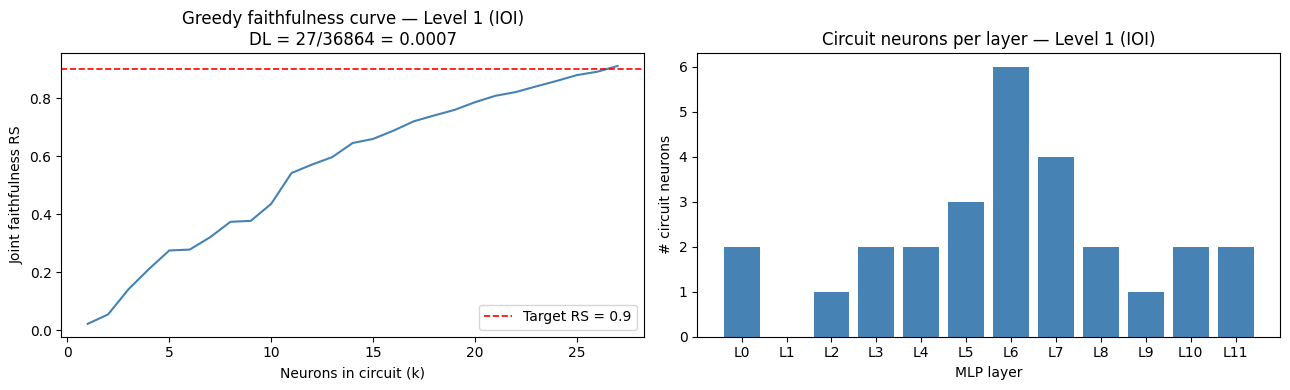

In [11]:
RS_TARGET = 0.90

# --- Pre-compute clean MLP activations for all layers ---
clean_acts_by_layer = {}
with torch.no_grad():
    for l in tqdm(range(N_LAYERS), desc="Caching clean activations"):
        buf = []
        for start in range(0, n_valid, BATCH_SIZE):
            end       = min(start + BATCH_SIZE, n_valid)
            batch_fps = final_positions[start:end]
            _, cache  = model.run_with_cache(
                ioi_tokens[start:end], names_filter=mlp_hook(l))
            acts      = cache[mlp_hook(l)]                        # [bs, seq, D_MLP]
            bs_       = acts.shape[0]
            buf.append(acts[torch.arange(bs_), batch_fps].cpu())  # [bs, D_MLP]
            del cache
        clean_acts_by_layer[l] = torch.cat(buf, dim=0)            # [n_valid, D_MLP]

# --- Flatten scores, sort, keep positive ---
all_rs        = torch.cat([neuron_scores[l] for l in range(N_LAYERS)])
total_neurons = N_LAYERS * D_MLP
flat_to_ln    = [(l, j) for l in range(N_LAYERS) for j in range(D_MLP)]
sorted_flat   = all_rs.argsort(descending=True).tolist()
pos_neurons   = [flat_to_ln[i] for i in sorted_flat if all_rs[i].item() > 0]
print(f"Neurons with positive approx RS: {len(pos_neurons)} / {total_neurons}")

# --- Faithfulness helper: exact activation patching for current circuit ---
def run_faithfulness(cbl):
    buf = []
    for start in range(0, n_valid, BATCH_SIZE):
        end       = min(start + BATCH_SIZE, n_valid)
        batch_fps = final_positions[start:end]
        hooks     = []
        for l in range(N_LAYERS):
            cj = cbl.get(l, [])
            if cj:
                ct = torch.tensor(cj, dtype=torch.long)
                ca = clean_acts_by_layer[l][start:end]             # [bs, D_MLP]
                def make_h(m=mean_abc_mlp[l], ct_=ct, ca_=ca, fp=batch_fps):
                    def fn(value, hook):
                        bs  = value.shape[0]
                        dev = value.device
                        ar  = torch.arange(bs, device=dev)
                        fpd = fp.to(dev)
                        value[ar, fpd] = m.to(dev).unsqueeze(0).expand(bs, -1)
                        value[ar[:, None], fpd[:, None], ct_.to(dev)] = (
                            ca_.to(dev)[:, ct_])
                        return value
                    return fn
                hooks.append((mlp_hook(l), make_h()))
            else:
                def make_a(m=mean_abc_mlp[l], fp=batch_fps):
                    def fn(value, hook):
                        bs  = value.shape[0]
                        dev = value.device
                        value[torch.arange(bs, device=dev), fp.to(dev)] = (
                            m.to(dev).unsqueeze(0).expand(bs, -1))
                        return value
                    return fn
                hooks.append((mlp_hook(l), make_a()))
        with torch.no_grad():
            buf.append(model.run_with_hooks(
                ioi_tokens[start:end], fwd_hooks=hooks).cpu())
        torch.cuda.empty_cache()
    ld = logit_diff(torch.cat(buf).to(device), ioi_valid, final_positions)
    return recovery_score(ld, corrupted_ld, clean_ld)

# --- Greedy circuit construction ---
circuit_by_layer = {}
faithfulness     = 0.0
rs_curve         = []

print(f"Building greedy circuit (target RS ≥ {RS_TARGET})...")
for k, (l, j) in enumerate(tqdm(pos_neurons, desc="Greedy steps")):
    circuit_by_layer.setdefault(l, []).append(j)
    faithfulness = run_faithfulness(circuit_by_layer)
    rs_curve.append(faithfulness)

    if (k + 1) % 25 == 0 or faithfulness >= RS_TARGET or k + 1 == len(pos_neurons):
        print(f"  k={k+1:5d}  RS={faithfulness:.4f}")

    if faithfulness >= RS_TARGET:
        break

n_circuit_neurons  = sum(len(v) for v in circuit_by_layer.values())
description_length = n_circuit_neurons / total_neurons
layer_n_circuit    = [len(circuit_by_layer.get(l, [])) for l in range(N_LAYERS)]

print()
print("=" * 58)
print("  Level 1 — Individual MLP neurons — IOI task")
print("=" * 58)
print(f"  RS target            : {RS_TARGET}")
print(f"  Max individual RS    : {all_rs.max():.4f}")
print(f"  Criterion 1  Faithfulness RS    : {faithfulness:.4f}")
print(f"  Criterion 2  Description length : {description_length:.6f}")
print(f"               ({n_circuit_neurons} / {total_neurons} neurons)")
print("=" * 58)

# --- Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(range(1, len(rs_curve) + 1), rs_curve, color="steelblue", linewidth=1.5)
ax1.axhline(RS_TARGET, color="red", linestyle="--", linewidth=1.2,
            label=f"Target RS = {RS_TARGET}")
ax1.set_xlabel("Neurons in circuit (k)")
ax1.set_ylabel("Joint faithfulness RS")
ax1.set_title(f"Greedy faithfulness curve — Level 1 (IOI)\n"
              f"DL = {n_circuit_neurons}/{total_neurons} = {description_length:.4f}")
ax1.legend()

ax2.bar(range(N_LAYERS), layer_n_circuit, color="steelblue")
ax2.set_xlabel("MLP layer")
ax2.set_ylabel("# circuit neurons")
ax2.set_title("Circuit neurons per layer — Level 1 (IOI)")
ax2.set_xticks(range(N_LAYERS))
ax2.set_xticklabels([f"L{l}" for l in range(N_LAYERS)])

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level1IOI_neuron_recovery.png", dpi=150)
plt.show()

In [12]:
results = {
    "level": 1,
    "task": "ioi",
    "method": "gradient_attribution_greedy_circuit",
    "n_layers": N_LAYERS,
    "d_mlp": D_MLP,
    "total_neurons": total_neurons,
    "n_eval": n_valid,
    "clean_ld_mean": clean_ld.mean().item(),
    "corrupted_ld_mean": corrupted_ld.mean().item(),
    "gap": (clean_ld - corrupted_ld).mean().item(),
    "circuit_selection": "greedy_cumulative",
    "rs_target": RS_TARGET,
    "max_individual_rs": all_rs.max().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_description_length": description_length,
    "criterion2_circuit_neurons": n_circuit_neurons,
    "criterion2_total_neurons": total_neurons,
    "circuit_by_layer": {str(l): circuit_by_layer.get(l, []) for l in range(N_LAYERS)},
    "layer_n_circuit": {str(l): layer_n_circuit[l] for l in range(N_LAYERS)},
    "all_recovery_scores_by_layer": {str(l): neuron_scores[l].tolist() for l in range(N_LAYERS)},
}

with open(RESULTS_DIR / "level1IOI_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {RESULTS_DIR}/level1IOI_results.json")

Saved to ../results/level1IOI/level1IOI_results.json
